## Aggregate Year-over-Year Changes for 1904-1978

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# ============================================================================
# CONFIGURATION: Historical Period Analysis (1904-1978)
# ============================================================================

START_YEAR = 1904
END_YEAR = 1978

# Aggregation method is average
AGGREGATE_LABEL = "Average Change per Park"

# Z-score threshold for outlier detection
Z_SCORE_THRESHOLD = 1

# Minimum number of parks required for a year to be included
MIN_PARKS_REQUIRED = 1

print(f"{'='*80}")
print(f"HISTORICAL PERIOD ANALYSIS: {START_YEAR}-{END_YEAR}")
print(f"Using AVERAGE for aggregate calculations")
print(f"{'='*80}\n")

HISTORICAL PERIOD ANALYSIS: 1904-1978
Using AVERAGE for aggregate calculations



In [45]:
# Load your data
df_raw = pd.read_csv('/Users/namithageorge/msai339/project/National-Parks-DS/Datasets/historic_park_data.csv')
df_raw['Total'] = (
    df_raw['Total']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print("Data shape:", df_raw.shape)
print("\nFirst few rows:")
print(df_raw.head())

# Aggregate to annual totals (in case there's monthly data)
df_annual = df_raw.groupby(['ParkName', 'Year'])['Total'].sum().reset_index()

# Filter to analysis period
df_annual = df_annual[(df_annual['Year'] >= START_YEAR) & (df_annual['Year'] <= END_YEAR)]

print(f"\nFiltered to {START_YEAR}-{END_YEAR}")
print(f"Data points: {len(df_annual)}")

# print(df_annual[df_annual['Year'] == 1905].shape[0])
# print(df_annual[df_annual['Year'] == 1906].shape[0])


# Pivot to parks × years
df_pivot = df_annual.pivot(index='ParkName', columns='Year', values='Total')
df = df_pivot.sort_index(axis=1)

# print("Annual parks in 1905:", set(df_annual[df_annual['Year'] == 1905]['ParkName']))
# print("Pivot parks in 1905:", set(df[df[1905].notna()].index))

# print("Annual parks in 1906:", set(df_annual[df_annual['Year'] == 1906]['ParkName']))
# print("Pivot parks in 1906:", set(df[df[1906].notna()].index))

# print(df.columns.tolist()[:15])
# print(set(type(c) for c in df.columns))

# print(df.columns[:20])
# print([type(c) for c in df.columns[:20]])


print("\nPivoted data shape:", df.shape)
print(f"Parks: {len(df)}, Years: {len(df.columns)}")
print(f"Year range: {df.columns.min()} to {df.columns.max()}")

missing_by_year = df.isna().sum(axis=0)
parks_with_data_by_year = len(df) - missing_by_year

print("\nParks with data by year (first 10 years):")
print(parks_with_data_by_year.head(10))

print("\nParks with data by year (last 10 years):")
print(parks_with_data_by_year.tail(10))


Data shape: (5282, 7)

First few rows:
    ParkName UnitCode       ParkType      Region State  Year    Total
0  Acadia NP     ACAD  National Park  Northeast     ME  1919  64000.0
1  Acadia NP     ACAD  National Park  Northeast     ME  1920  66500.0
2  Acadia NP     ACAD  National Park  Northeast     ME  1921  69836.0
3  Acadia NP     ACAD  National Park  Northeast     ME  1922  73779.0
4  Acadia NP     ACAD  National Park  Northeast     ME  1923  64200.0

Filtered to 1904-1978
Data points: 2436

Pivoted data shape: (55, 75)
Parks: 55, Years: 75
Year range: 1904 to 1978

Parks with data by year (first 10 years):
Year
1904     6
1905     6
1906     7
1907     7
1908     8
1909     8
1910     9
1911    10
1912    10
1913    10
dtype: int64

Parks with data by year (last 10 years):
Year
1969    48
1970    49
1971    51
1972    52
1973    53
1974    53
1975    53
1976    54
1977    54
1978    55
dtype: int64


In [46]:
# ============================================================================
# STEP 2: Year-over-Year Changes
# ============================================================================
# print(df[[1905, 1906]].notna().sum())

yoy_changes = df.diff(axis=1)

valid_parks_per_year = yoy_changes.notna().sum(axis=0)
print("\nValid parks per year (first 10):")
print(valid_parks_per_year.head(10))

print("\nValid parks per year (last 10):")
print(valid_parks_per_year.tail(10))


Valid parks per year (first 10):
Year
1904     0
1905     6
1906     5
1907     7
1908     7
1909     8
1910     8
1911     9
1912    10
1913    10
dtype: int64

Valid parks per year (last 10):
Year
1969    48
1970    48
1971    49
1972    51
1973    52
1974    53
1975    53
1976    53
1977    54
1978    54
dtype: int64


In [47]:
# ============================================================================
# STEP 3: OUTLIER DETECTION
# ============================================================================

print("\n" + "="*80)
print("METHOD 1: Z-SCORE OUTLIER DETECTION (PER PARK)")
print("="*80)

z_scores = pd.DataFrame(index=yoy_changes.index, columns=yoy_changes.columns)

for park in yoy_changes.index:
    park_changes = yoy_changes.loc[park].dropna()
    mean_change = park_changes.mean()
    std_change = park_changes.std()

    if std_change > 0:
        z_scores.loc[park] = (yoy_changes.loc[park] - mean_change) / std_change

outliers_z = z_scores.abs() > Z_SCORE_THRESHOLD

print("\nOutliers per year:")
print(outliers_z.sum(axis=0))

# ============================================================================
# Method 2: Aggregate Year-Level Outliers (Average Only)
# ============================================================================

print("\n" + "="*80)
print("METHOD 2: AGGREGATE YEAR-LEVEL OUTLIERS (USING AVERAGE)")
print("="*80)

aggregate_changes = yoy_changes.mean(axis=0, skipna=True)

years_with_sufficient_data = valid_parks_per_year >= MIN_PARKS_REQUIRED
aggregate_changes_filtered = aggregate_changes[years_with_sufficient_data]

agg_mean = aggregate_changes_filtered.mean()
agg_std = aggregate_changes_filtered.std()

aggregate_z_scores = (aggregate_changes_filtered - agg_mean) / agg_std

outlier_years = aggregate_z_scores[aggregate_z_scores.abs() > Z_SCORE_THRESHOLD]

print("\nAggregate Z-Scores:")
print(aggregate_z_scores.sort_values())
print(f"\nOutlier Years: {list(outlier_years.index)}")

parks_with_outliers = outliers_z.sum(axis=0)
print("\nParks with outliers per year (top 10):")
print(parks_with_outliers[years_with_sufficient_data].sort_values(ascending=False).head(10))



METHOD 1: Z-SCORE OUTLIER DETECTION (PER PARK)

Outliers per year:
Year
1904     0
1905     0
1906     0
1907     0
1908     0
        ..
1974    31
1975    32
1976    20
1977    20
1978    27
Length: 75, dtype: int64

METHOD 2: AGGREGATE YEAR-LEVEL OUTLIERS (USING AVERAGE)

Aggregate Z-Scores:
Year
1942   -3.593623
1971   -2.427364
1974   -1.874920
1943   -1.640227
1967   -1.070397
          ...   
1960    1.950008
1962    2.061942
1965    2.380682
1972    2.397613
1946    2.483591
Length: 74, dtype: float64

Outlier Years: [1942, 1943, 1946, 1960, 1962, 1965, 1966, 1967, 1970, 1971, 1972, 1973, 1974, 1975, 1976]

Parks with outliers per year (top 10):
Year
1975    32
1974    31
1973    28
1978    27
1942    22
1971    21
1977    20
1976    20
1946    16
1962    16
dtype: int64


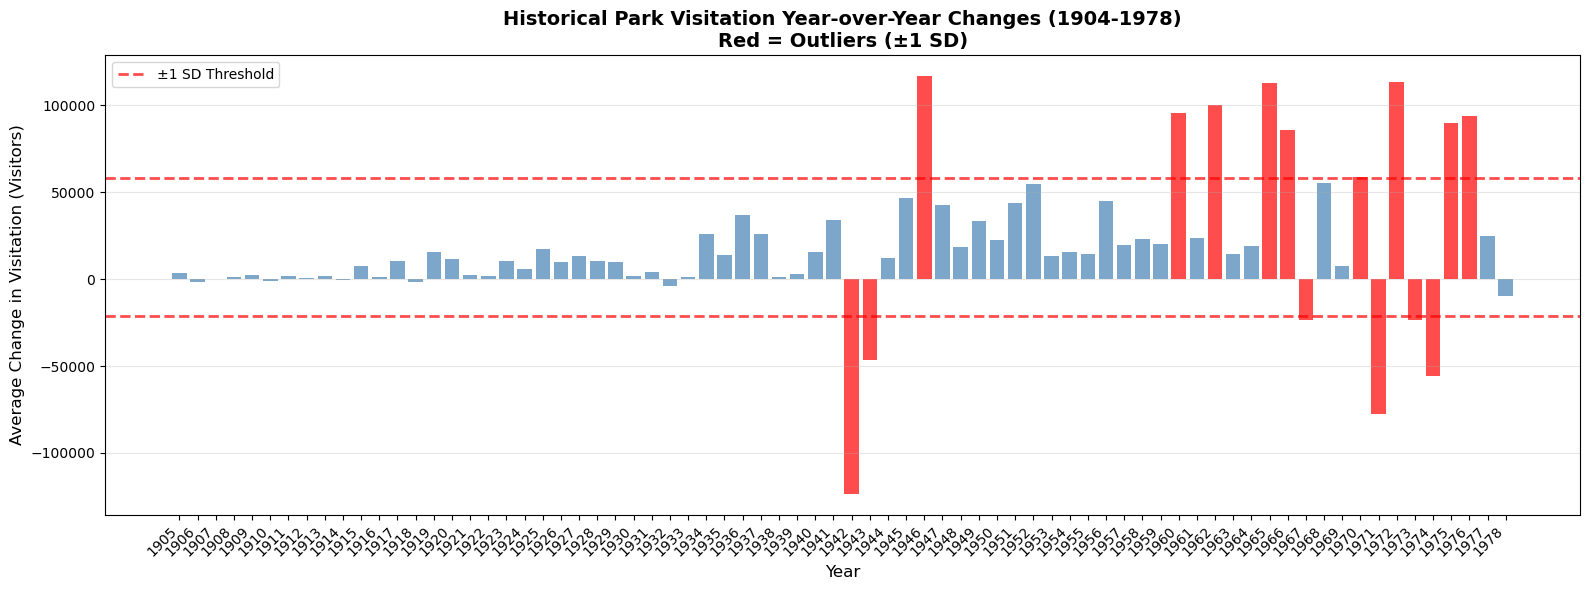

In [57]:
# ============================================================================
# STEP 4: Visualization
# ============================================================================
plt.figure(figsize=(16, 6))  # Better aspect ratio for readability
colors = ['red' if abs(z) > Z_SCORE_THRESHOLD else 'steelblue' for z in aggregate_z_scores]
plt.bar(aggregate_changes_filtered.index.astype(str),
        aggregate_changes_filtered.values, color=colors, alpha=0.7)

# Add threshold lines with labels
plt.axhline(y=agg_mean + Z_SCORE_THRESHOLD * agg_std, color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'±{Z_SCORE_THRESHOLD} SD Threshold')
plt.axhline(y=agg_mean - Z_SCORE_THRESHOLD * agg_std, color='red', linestyle='--', 
            linewidth=2, alpha=0.7)
# plt.axhline(y=agg_mean, color='black', linestyle='-', linewidth=1, alpha=0.3, 
        #     label=f'Mean ({agg_mean:,.0f})')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Change in Visitation (Visitors)', fontsize=12)
plt.title(f'Historical Park Visitation Year-over-Year Changes ({START_YEAR}-{END_YEAR})\n'
          f'Red = Outliers (±{Z_SCORE_THRESHOLD} SD)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')  # Added ha='right' for better label alignment
plt.legend(loc='upper left', fontsize=10)  # Add legend
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

filename = f'historical_outliers_{START_YEAR}_{END_YEAR}.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

In [58]:
# ============================================================================
# STEP 5: Summary Report
# ============================================================================

print("\n" + "="*80)
print("SUMMARY REPORT")
print("="*80)

print(f"\nAnalysis Period: {START_YEAR}-{END_YEAR}")
print("Aggregation Method: AVERAGE ONLY")
print(f"Total Parks in Dataset: {len(df)}")
print(f"Years Analyzed: {len(aggregate_changes_filtered)}")

print("\n--- Outlier Years ---")
print(list(outlier_years.index))

if len(outlier_years) > 0:
    print("\nTop outlier years:")
    for year in outlier_years.sort_values(key=abs, ascending=False).head(5).index:
        z_val = aggregate_z_scores[year]
        change_val = aggregate_changes_filtered[year]
        direction = "increase" if change_val > 0 else "decrease"
        print(f"  {year}: Z = {z_val:.2f}, Change = {change_val:,.0f} ({direction})")

park_outlier_counts = outliers_z.sum(axis=1)
print("\nParks with most outliers:")
print(park_outlier_counts.sort_values(ascending=False).head(5))

results_df = pd.DataFrame({
    'Year': aggregate_changes_filtered.index,
    'Aggregate_Change': aggregate_changes_filtered.values,
    'Z_Score': aggregate_z_scores.values,
    'Is_Outlier': aggregate_z_scores.abs() > Z_SCORE_THRESHOLD,
    'Parks_With_Data': valid_parks_per_year[years_with_sufficient_data].values
})

csv_filename = f'outlier_analysis_{START_YEAR}_{END_YEAR}.csv'
results_df.to_csv(csv_filename, index=False)

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print(f"Chart saved as: {filename}")
print("="*80)


SUMMARY REPORT

Analysis Period: 1904-1978
Aggregation Method: AVERAGE ONLY
Total Parks in Dataset: 55
Years Analyzed: 74

--- Outlier Years ---
[1942, 1943, 1946, 1960, 1962, 1965, 1966, 1967, 1970, 1971, 1972, 1973, 1974, 1975, 1976]

Top outlier years:
  1942: Z = -3.59, Change = -123,501 (decrease)
  1946: Z = 2.48, Change = 116,745 (increase)
  1971: Z = -2.43, Change = -77,396 (decrease)
  1972: Z = 2.40, Change = 113,346 (increase)
  1965: Z = 2.38, Change = 112,677 (increase)

Parks with most outliers:
ParkName
Lassen Volcanic NP    15
Kings Canyon NP       15
Crater Lake NP        15
Mount Rainier NP      15
Sequoia NP            14
dtype: int64

ANALYSIS COMPLETE
Chart saved as: historical_outliers_1904_1978.png


In [22]:
# ============================================================================
# STEP 5: Summary Report
# ============================================================================

print("\n" + "="*80)
print("SUMMARY REPORT")
print("="*80)

print(f"\nAnalysis Period: {START_YEAR}-{END_YEAR}")
print("Aggregation Method: AVERAGE ONLY")
print(f"Total Parks in Dataset: {len(df)}")
print(f"Years Analyzed: {len(aggregate_changes_filtered)}")

print("\n--- Outlier Years ---")
print(list(outlier_years.index))

if len(outlier_years) > 0:
    print("\nTop outlier years:")
    for year in outlier_years.sort_values(key=abs, ascending=False).head(5).index:
        z_val = aggregate_z_scores[year]
        change_val = aggregate_changes_filtered[year]
        direction = "increase" if change_val > 0 else "decrease"
        print(f"  {year}: Z = {z_val:.2f}, Change = {change_val:,.0f} ({direction})")

park_outlier_counts = outliers_z.sum(axis=1)
print("\nParks with most outliers:")
print(park_outlier_counts.sort_values(ascending=False).head(5))

results_df = pd.DataFrame({
    'Year': aggregate_changes_filtered.index,
    'Aggregate_Change': aggregate_changes_filtered.values,
    'Z_Score': aggregate_z_scores.values,
    'Is_Outlier': aggregate_z_scores.abs() > Z_SCORE_THRESHOLD,
    'Parks_With_Data': valid_parks_per_year[years_with_sufficient_data].values
})

csv_filename = f'outlier_analysis_{START_YEAR}_{END_YEAR}.csv'
results_df.to_csv(csv_filename, index=False)

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print(f"Chart saved as: {filename}")
print("="*80)


SUMMARY REPORT

Analysis Period: 1904-1978
Aggregation Method: AVERAGE ONLY
Total Parks in Dataset: 55
Years Analyzed: 36

--- Outlier Years ---
[1942, 1962, 1963]

Top outlier years:
  1942: Z = -2.62, Change = -378 (decrease)
  1962: Z = -2.15, Change = -300 (decrease)
  1963: Z = 2.09, Change = 400 (increase)

Parks with most outliers:
ParkName
Denali NP & PRES    1
Hot Springs NP      0
Isle Royale NP      0
Joshua Tree NP      0
Katmai NP & PRES    0
dtype: int64

ANALYSIS COMPLETE
Chart saved as: historical_outliers_1904_1978.png
